Pour garder une stabilité dans le modèle

In [23]:
import numpy as np
import tensorflow as tf
import random

# Figer l'aléatoire pour la reproductibilité
seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)
tf.random.set_seed(seed_value)

On fait comme dit dans la séance 8, on va prédire la tendance sur 5 jours pour éviter les problèmes de bruit sur 1 jour. Ainsi on modifie, uniquement y sans casser X

In [24]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler 

# 1. On recharge le df initial (avant le split)
df = pd.read_csv('../data/processed/chip_chain_master_lstm.csv')
df = pd.get_dummies(df, columns=['HMM_State'], prefix='Regime', dtype=int)

TARGET_ASSET = 'NVDA'

# On calcule le rendement logarithmique moyen des 5 PROCHAINS JOURS
# Le shift(-5) remonte les données, le rolling(5) fait la moyenne
future_5d_return = df[TARGET_ASSET].shift(-5).rolling(window=5).mean()

# NOUVELLE CIBLE : 1 si la moyenne des 5 prochains jours est positive, sinon 0
df['Target_5D'] = np.where(future_5d_return > 0, 1, 0)

# On doit supprimer les 5 dernières lignes du dataset (qui n'ont pas de futur)
df = df.dropna().reset_index(drop=True)

# Récupération des masques pour le train et le test
train_mask = df['Dataset_Type'] == 'Train'
test_mask = df['Dataset_Type'] == 'Test'

features_cols = [col for col in df.columns if col not in ['Date', 'Dataset_Type', 'Target_5D']]
scaler = StandardScaler()
train_scaled = scaler.fit_transform(df.loc[train_mask, features_cols])
test_scaled = scaler.transform(df.loc[test_mask, features_cols])

X_scaled_full = np.vstack((train_scaled, test_scaled))
y_full = df['Target_5D'].values  # <--- On utilise la NOUVELLE cible lissée
type_full = df['Dataset_Type'].values

TIME_STEPS = 21
X_3d_train, y_3d_train, X_3d_test, y_3d_test = [], [], [], []

for i in range(len(X_scaled_full) - TIME_STEPS):
    window = X_scaled_full[i : i + TIME_STEPS]
    target_val = y_full[i + TIME_STEPS]
    day_type = type_full[i + TIME_STEPS] 
    
    if day_type == 'Train':
        X_3d_train.append(window)
        y_3d_train.append(target_val)
    else:
        X_3d_test.append(window)
        y_3d_test.append(target_val)

X_train_3d = np.array(X_3d_train)
y_train = np.array(y_3d_train)
X_test_3d = np.array(X_3d_test)
y_test = np.array(y_3d_test)

print("Nouvelle cible lissée sur 5 jours créée !")

Nouvelle cible lissée sur 5 jours créée !


On entraine le modèle

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# On construit le modèle avec les best_hps du Keras Tuner
model = Sequential()
model.add(Input(shape=(TIME_STEPS, len(features_cols))))

model.add(LSTM(units=32, 
               activation='tanh',
               kernel_regularizer=l2(1e-6),
               recurrent_dropout=0.2))

# model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=5e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Entraînement sur la cible lissée
history = model.fit(
    X_train_3d, y_train, # Les nouvelles données !
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    shuffle=False
)

# ÉVALUATION OUT-OF-SAMPLE
_, test_acc = model.evaluate(X_test_3d, y_test, verbose=0)
print(f"\nAccuracy sur la Tendance à 5 Jours (Test Set) : {test_acc * 100:.2f}%")

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5111 - loss: 0.7154 - val_accuracy: 0.4323 - val_loss: 0.7314
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5044 - loss: 0.7120 - val_accuracy: 0.4371 - val_loss: 0.7280
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5145 - loss: 0.7103 - val_accuracy: 0.4561 - val_loss: 0.7250
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5283 - loss: 0.7049 - val_accuracy: 0.4608 - val_loss: 0.7224
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5187 - loss: 0.7080 - val_accuracy: 0.4561 - val_loss: 0.7199
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5233 - loss: 0.7052 - val_accuracy: 0.4537 - val_loss: 0.7177
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5460 - loss: 0.7028 - val_accuracy: 0.4561 - val_loss: 0.7156
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5187 - loss: 0.7038 - val_accuracy: 0.

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Calcul de la Baseline (Le marché brut)
baseline_accuracy = max(np.mean(y_test), 1 - np.mean(y_test))
print(f"Accuracy du marché (Baseline si on dit toujours 'Hausse') : {baseline_accuracy * 100:.2f}%")
print(f"Accuracy du Modèle LSTM : {test_acc * 100:.2f}%")

# 2. Prédictions
y_pred_probs = model.predict(X_test_3d)
y_pred = (y_pred_probs > 0.50).astype(int)

# 3. Matrice
print("\nMatrice de Confusion :")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred))

Accuracy du marché (Baseline si on dit toujours 'Hausse') : 57.99%
Accuracy du Modèle LSTM : 55.87%
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

Matrice de Confusion :
[[ 67 230]
 [ 82 328]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.45      0.23      0.30       297
           1       0.59      0.80      0.68       410

    accuracy                           0.56       707
   macro avg       0.52      0.51      0.49       707
weighted avg       0.53      0.56      0.52       707



On save le modèle, car comme pour un casino avoir juste 53% chance de gagner pour le casino est 47% pour les autres, le profil arrive, de plus il n'agit pas bêtement en mettant que hausse, néanmoins on doit revérifier s'il travaille bien avec d'autre indicteur

In [27]:
model.save('../data/tensors/chip_chain_lstm.keras')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Dates: 707, Returns: 707, Preds: 707

           Métrique Buy & Hold (NVDA) Stratégie LSTM (Long/Cash)
   Rendement Cumulé           259.23%                    120.85%
Sharpe Ratio (Ann.)              1.20                       0.88
       Max Drawdown           -41.14%                    -47.03%


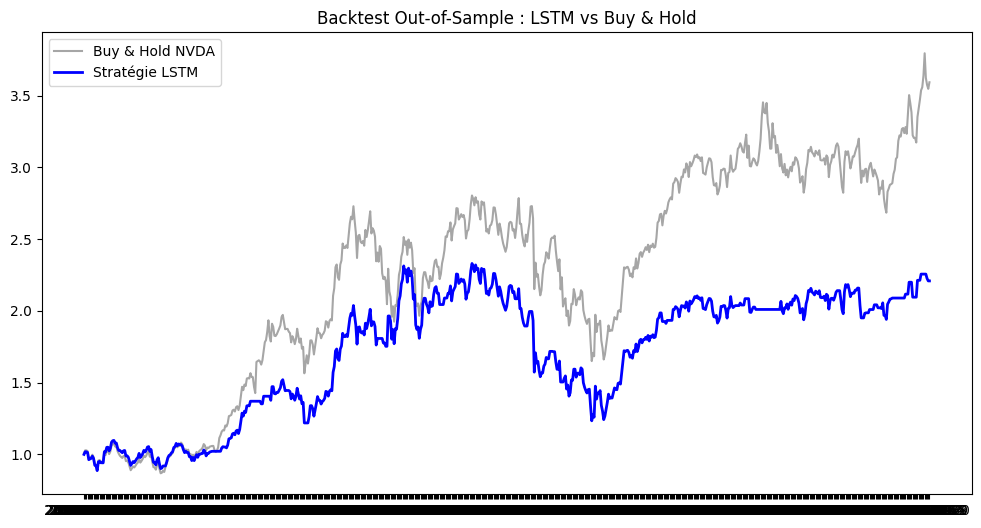

In [28]:
# 1. Alignement parfait des données (Pas besoin de slice TIME_STEPS !)
test_dates = df.loc[test_mask, 'Date'].values
real_returns = df.loc[test_mask, TARGET_ASSET].values # On prend les vrais rendements quotidiens (non lissés) pour le PnL

# On vérifie les dimensions
y_pred_probs = model.predict(X_test_3d).flatten()
print(f"Dates: {len(test_dates)}, Returns: {len(real_returns)}, Preds: {len(y_pred_probs)}\n")

# 2. Construction du DataFrame de Backtest
backtest_df = pd.DataFrame({
    'Return_Real': real_returns,
    'Prob_Up': y_pred_probs
}, index=test_dates)

# Règle de décision : Si proba > 0.50, on est Long (1), sinon Cash (0)
backtest_df['Position'] = np.where(backtest_df['Prob_Up'] > 0.50, 1, 0)

# ⚠️ DÉCALAGE CRUCIAL (Look-Ahead Bias Prevention)
# La prédiction faite à la fin du Jour T s'applique au rendement du Jour T+1
backtest_df['Position_Delayed'] = backtest_df['Position'].shift(1).fillna(0)

# Rendements de la stratégie
backtest_df['Return_Strategy'] = backtest_df['Position_Delayed'] * backtest_df['Return_Real']

# 3. Calcul des Métriques Clés
def calculate_metrics(returns):
    # Rendement cumulé
    cum_returns = np.prod(1 + returns) - 1
    
    # Rendement moyen et volatilité annualisés
    mean_ann = np.mean(returns) * 252
    vol_ann = np.std(returns) * np.sqrt(252)
    
    # Ratio de Sharpe (Taux sans risque à 0% pour simplifier)
    sharpe = mean_ann / vol_ann if vol_ann != 0 else 0
    
    # Maximum Drawdown
    equity_curve = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(equity_curve)
    drawdowns = (equity_curve - running_max) / running_max
    max_dd = np.min(drawdowns) if len(drawdowns) > 0 else 0
    
    return cum_returns, sharpe, max_dd

cum_bh, sharpe_bh, max_dd_bh = calculate_metrics(backtest_df['Return_Real'])
cum_strat, sharpe_strat, max_dd_strat = calculate_metrics(backtest_df['Return_Strategy'])

# 4. Affichage du Tableau Comparatif
results_summary = pd.DataFrame({
    'Métrique': ['Rendement Cumulé', 'Sharpe Ratio (Ann.)', 'Max Drawdown'],
    'Buy & Hold (NVDA)': [f"{cum_bh * 100:.2f}%", f"{sharpe_bh:.2f}", f"{max_dd_bh * 100:.2f}%"],
    'Stratégie LSTM (Long/Cash)': [f"{cum_strat * 100:.2f}%", f"{sharpe_strat:.2f}", f"{max_dd_strat * 100:.2f}%"]
})

print(results_summary.to_string(index=False))

# Optionnel : Afficher la courbe d'équité pour voir où l'IA a surperformé
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(np.cumprod(1 + backtest_df['Return_Real']), label='Buy & Hold NVDA', color='gray', alpha=0.7)
plt.plot(np.cumprod(1 + backtest_df['Return_Strategy']), label='Stratégie LSTM', color='blue', linewidth=2)
plt.title('Backtest Out-of-Sample : LSTM vs Buy & Hold')
plt.legend()
plt.show()

Les indicateurs sont mauvais, il montre que le modèle prédit en retard, regardons les features les plus importantes pour mieux comprendre

⏳ Lancement de l'Explainer SHAP (Cela peut prendre 1 à 3 minutes)...


c:\Dev\ChipChainReaction\.venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_2
Received: inputs=['Tensor(shape=(100, 21, 51))']
  warnings.warn(msg)
c:\Dev\ChipChainReaction\.venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_2
Received: inputs=['Tensor(shape=(50, 21, 51))']
  warnings.warn(msg)


Shape des SHAP values (Doit être 100, 21, 51) : (100, 21, 51, 1)


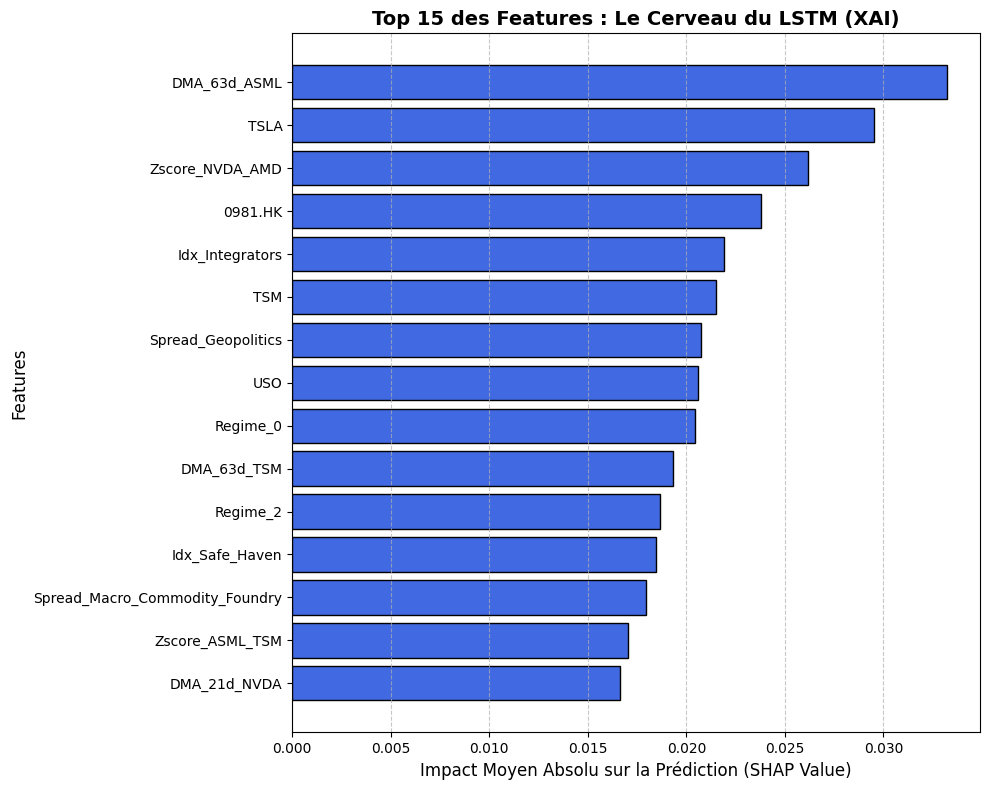

In [29]:
import shap
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Chargement des données et du modèle
model = tf.keras.models.load_model('../data/tensors/chip_chain_lstm.keras')
data = np.load('../data/tensors/lstm_tensors.npz')

X_train_3d = data['X_train']
X_test_3d = data['X_test']

# Pour avoir le nom exact de tes 51 features, tu dois recharger rapidement le dataframe
df = pd.read_csv('../data/processed/chip_chain_master_lstm.csv')
df = pd.get_dummies(df, columns=['HMM_State'], prefix='Regime', dtype=int)
features_cols = [col for col in df.columns if col not in ['Date', 'Dataset_Type', 'Target']]

# 2. Préparation pour SHAP (Échantillonnage car SHAP est très gourmand)
# On prend 100 jours au hasard dans le train comme référence (Background)
np.random.seed(42)
background_idx = np.random.choice(X_train_3d.shape[0], 100, replace=False)
background = X_train_3d[background_idx]

# On va expliquer 100 jours du Test Set
test_explain = X_test_3d[:100]

print("⏳ Lancement de l'Explainer SHAP (Cela peut prendre 1 à 3 minutes)...")

# 3. Utilisation du GradientExplainer (Idéal pour les LSTM Keras)
explainer = shap.GradientExplainer(model, background)
shap_values_3d = explainer.shap_values(test_explain)

# Attention, avec TF2, shap_values_3d est parfois une liste ou un tenseur direct.
if isinstance(shap_values_3d, list):
    shap_values_3d = shap_values_3d[0]

# 4. Aplatissement (Flatten) de la dimension temporelle (TIME_STEPS = 21)
# On veut savoir quelle feature est importante, peu importe le jour dans la fenêtre
# On fait la somme absolue des valeurs SHAP sur l'axe du temps (axis=1)
shap_values_2d = np.sum(np.abs(shap_values_3d), axis=1)
test_explain_2d = np.mean(test_explain, axis=1) # Valeur moyenne de la feature sur les 21 jours

# 1. Vérification de sécurité (Extraction de la liste si TF2 l'a encapsulée)
if isinstance(shap_values_3d, list):
    shap_values_3d = shap_values_3d[0]

print(f"Shape des SHAP values (Doit être 100, 21, 51) : {np.array(shap_values_3d).shape}")

# 2. LA MATHÉMATIQUE DE L'EXPLICABILITÉ
# Étape A : Valeur absolue (On s'en fiche de si ça fait monter ou baisser, on veut l'impact)
shap_abs = np.abs(shap_values_3d)

# Étape B : Somme sur la dimension temporelle (axe 1 = les 21 jours)
# On veut savoir le poids total de la feature sur toute la fenêtre d'un mois
shap_time_sum = np.sum(shap_abs, axis=1)

# Étape C : Moyenne sur les 100 prédictions de test (axe 0) pour avoir un score global
global_importance = np.mean(shap_time_sum, axis=0).flatten()  # On a maintenant un vecteur de 51 valeurs

# 3. Création d'un classement propre avec Pandas
importance_df = pd.DataFrame({
    'Feature': features_cols,
    'Importance': global_importance
})

# On trie et on garde le Top 15
top_15_df = importance_df.sort_values(by='Importance', ascending=True).tail(15)

# 4. Dessin du Graphique (Méthode robuste Matplotlib)
plt.figure(figsize=(10, 8))
plt.barh(top_15_df['Feature'], top_15_df['Importance'], color='royalblue', edgecolor='black')

plt.title('Top 15 des Features : Le Cerveau du LSTM (XAI)', fontsize=14, fontweight='bold')
plt.xlabel('Impact Moyen Absolu sur la Prédiction (SHAP Value)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Dans les features on voit :
- en 1 et 10 des données trimestriels glissantes, mais c'est un indicateur très lent, ainsi par exemple cette indicateur peut prendre trois semaines a s'orienter vers le bas, refuser de voir la crise pendant 3 semaines et lors du rebond la voir et donc faire mal deux fois
- ASML, 0981.HK, TSM et Spread_Geopolitics qui met en avant que l'IA a compris tout seul les liens et chaine vers NVDA
- une macro-économie :
    - USO en 8 : le modèle voit le lien du pétrole et énergie dans la chaine
    - Regime_0 (Krach) en 9 et Regime_2 (Bull) en 11 : le HMM a servi pour la compréhension du LSTM
    - Zscore_NVDA_AMD en 3 : le modèle comprend qu'il y a un arbitrage entre les deux si l'un monte trop vite par rapport à l'autre, le LSTM s'attend à un rattrapage
- TSLA en 2 : c'est une surprise mais ça peut se comprendre Tesla est un gros acheteur de puces IA pour l'automobile (si ce n'est le plus gros) et son supercalculateur Dojo

Après cette visualisation, on part donc de l'hypothèse que le problème vient des features trimestriels qu'on va donc supprimer, la prochaine séance va donc avoir pour but de vérifier l'hypothèse.